## 1. EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/base nova completa.csv', encoding='cp1252')
print(df.shape)
df.head()

(244, 260)


,Tipo de unidade,Distrito Sanitário,Quantidade atendida — Indicador 1,Total avaliado — Indicador 1,Meta — Indicador 1,Desempenho consolidado — Indicador 1,Valor informado — Subindicador 2.1,Meta — Subindicador 2.1,Desempenho — Subindicador 2.1,Quantidade atendida — Subindicador 2.2,...,Quantidade atendida — Subindicador 5.IV,Total avaliado — Subindicador 5.IV,Meta — Subindicador 5.IV,Desempenho consolidado — Subindicador 5.IV,Desempenho consolidado — Indicador 5,Desempenho geral,Desempenho consolidado — Indicador 1.1,Desempenho consolidado — Indicador 2.1,Desempenho consolidado — Indicador 3.1,Desempenho consolidado — Indicador 4
0,SAE,I,221,284,100%,99%,73,100%,0%,129,...,166,214,90%,86.2%,86%,81.61%,19.80%,10.00%,62.18%,46.76%
1,SAE,III,81,113,100%,100%,70,100%,0%,293,...,228,272,90%,93.1%,86%,190.49%,20.00%,10.00%,248.72%,45.12%
2,SAE,IV,115,142,100%,75%,72,100%,0%,393,...,377,472,90%,88.7%,84%,187.90%,15.00%,10.00%,248.72%,45.71%
3,NDI,III,149,207,100%,72%,69,100%,0%,451,...,348,425,90%,91.0%,88%,179.23%,14.40%,10.00%,248.72%,31.56%
4,NDI,VI,387,490,100%,78%,69,100%,0%,237,...,377,419,90%,100.0%,71%,179.89%,15.60%,10.00%,248.72%,31.50%


## Tipos das colunas

In [2]:
df.dtypes.value_counts()

object     201
int64       48
float64     11
Name: count, dtype: int64

In [3]:
df[['Desempenho consolidado — Indicador 1', 'Desempenho geral']].head()

,Desempenho consolidado — Indicador 1,Desempenho geral
0,99%,81.61%
1,100%,190.49%
2,75%,187.90%
3,72%,179.23%
4,78%,179.89%


In [4]:
def para_numero(coluna):
    texto = coluna.astype(str).str.strip().str.replace(',', '')
    valor = pd.to_numeric(texto.str.rstrip('%'), errors='coerce')
    return valor / texto.str.endswith('%').map({True: 100, False: 1})

eda = pd.DataFrame({
    'tipo': df['Tipo de unidade'],
    'distrito': df['Distrito Sanitário'],
    'ind1': para_numero(df['Desempenho consolidado — Indicador 1']),
    'ind2': para_numero(df['Desempenho consolidado — Indicador 2']),
    'ind3': para_numero(df['Desempenho consolidado — Indicador 3']),
    'ind4': para_numero(df['Desempenho consolidado — Indicador 4']) / 0.4,  # vem multiplicado pelo peso (40%)
    'geral': para_numero(df['Desempenho geral']),
})
eda['familia'] = eda['tipo'].str.split().str[0]
eda.describe().round(3)

,ind1,ind2,ind3,ind4,geral
count,244.000,244.000,244.000,244.000,244.000
mean,0.572,0.472,1.608,1.224,0.830
std,0.242,0.199,0.825,1.186,0.346
min,0.000,0.000,0.000,-0.130,0.000
25%,0.500,0.500,1.890,0.800,0.897
50%,0.500,0.500,1.890,0.800,0.897
75%,0.750,0.500,1.890,0.937,0.947
max,1.000,0.930,3.110,6.583,1.905


In [5]:
# as duas primeiras colunas identificam a unidade e são categóricas; as outras 258 são números
# guardados como texto (com % e vírgula de milhar), por isso o pandas lê a maioria como object
convertida = df.copy()
convertida[df.columns[2:]] = df[df.columns[2:]].apply(para_numero)

categoricas = convertida.select_dtypes(exclude='number').columns.tolist()
numericas = convertida.select_dtypes(include='number').columns.tolist()
print('registros:', convertida.shape[0], '| atributos:', convertida.shape[1])
print('categóricas:', categoricas, '| valores distintos:', convertida[categoricas].nunique().tolist())
print('numéricas:', len(numericas))

# cada coluna numérica cumpre um papel dentro do indicador, dado pelo começo do nome
descricao = {
    'Quantidade atendida': 'numerador: casos que cumpriram o critério',
    'Total avaliado': 'denominador: casos avaliados no período',
    'Valor informado': 'valor bruto lançado pela unidade',
    'Meta': 'meta fixada pela portaria',
    'Desempenho': 'nota do subindicador',
    'Desempenho consolidado': 'nota do indicador ou do bloco (as quatro últimas são os pontos)',
    'Desempenho geral': 'resultado final da unidade: o alvo',
}
papel = pd.Series(numericas).str.split(' — ').str[0].value_counts()
pd.DataFrame({'colunas': papel, 'tipo depois da conversão': 'float', 'descrição': papel.index.map(descricao)})

registros: 244 | atributos: 260
categóricas: ['Tipo de unidade', 'Distrito Sanitário'] | valores distintos: [20, 8]
numéricas: 258


,colunas,tipo depois da conversão,descrição
Meta,67,float,meta fixada pela portaria
Desempenho,60,float,nota do subindicador
Quantidade atendida,40,float,numerador: casos que cumpriram o critério
Total avaliado,38,float,denominador: casos avaliados no período
Valor informado,28,float,valor bruto lançado pela unidade
Desempenho consolidado,24,float,nota do indicador ou do bloco (as quatro últim...
Desempenho geral,1,float,resultado final da unidade: o alvo


## Tipos de unidade e distritos

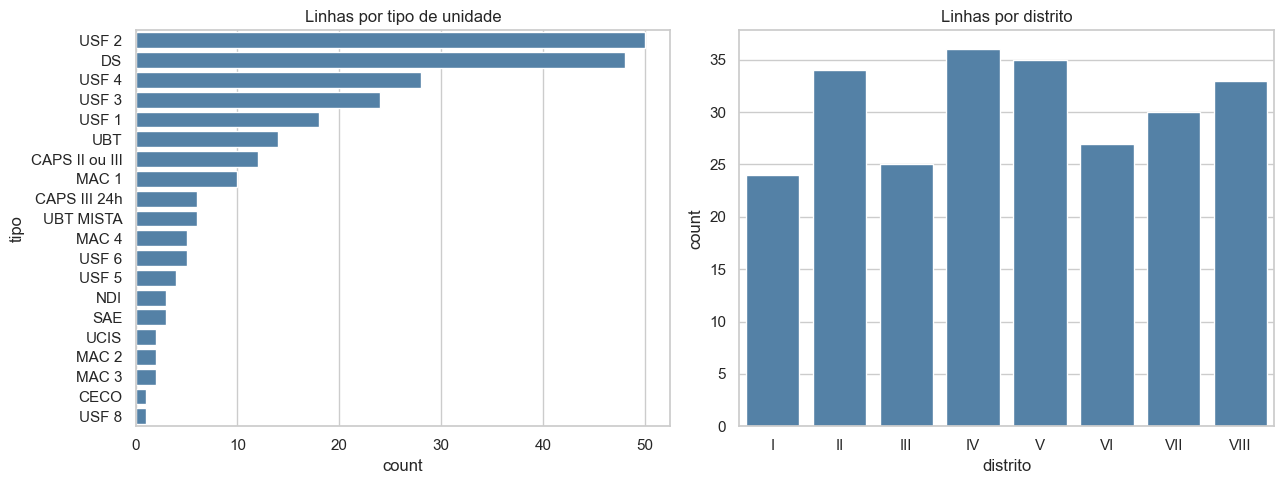

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=eda, y='tipo', order=eda['tipo'].value_counts().index, ax=eixos[0], color='steelblue')
eixos[0].set_title('Linhas por tipo de unidade')
sns.countplot(data=eda, x='distrito', order=sorted(eda['distrito'].unique()), ax=eixos[1], color='steelblue')
eixos[1].set_title('Linhas por distrito')
plt.tight_layout()
plt.show()

`DS` é a linha do próprio distrito sanitário, não de uma unidade. O distrito é avaliado com outra versão dos indicadores, então essas linhas saem da modelagem.

In [7]:
unidades = eda[eda['tipo'] != 'DS'] # desconsiderar as linhas de distrito sanitario
print('unidades:', len(unidades), '| linhas de distrito:', (eda['tipo'] == 'DS').sum())

unidades: 196 | linhas de distrito: 48


## Distribuição das notas

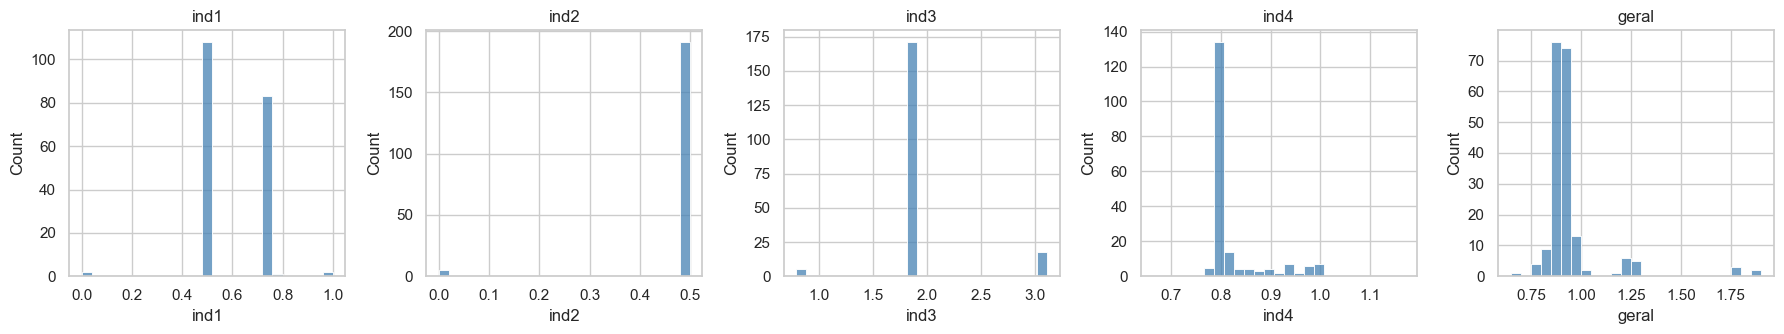

In [8]:
colunas = ['ind1', 'ind2', 'ind3', 'ind4', 'geral']

fig, eixos = plt.subplots(1, 5, figsize=(18, 3.5))
for eixo, coluna in zip(eixos, colunas):
    sns.histplot(unidades[coluna], bins=25, ax=eixo, color='steelblue')
    eixo.set_title(coluna)
plt.tight_layout()
plt.show()

In [9]:
unidades[colunas].skew().round(2)

ind1    -0.38
ind2    -6.07
ind3     1.31
ind4     2.31
geral    3.84
dtype: float64

In [10]:
# regra do IQR: fora de [Q1 - 1,5 IQR, Q3 + 1,5 IQR] é candidato a outlier. como as notas andam em
# degraus, o IQR fica estreito e quase todo tipo que foge do padrão da USF acaba marcado.
# o tratamento fica no caderno 2
q1, q3 = unidades[colunas].quantile(0.25), unidades[colunas].quantile(0.75)
fora = (unidades[colunas] < q1 - 1.5 * (q3 - q1)) | (unidades[colunas] > q3 + 1.5 * (q3 - q1))
pd.DataFrame({'outliers': fora.sum(), '% das unidades': (fora.mean() * 100).round(1)})

,outliers,% das unidades
ind1,2,1.0
ind2,5,2.6
ind3,25,12.8
ind4,35,17.9
geral,29,14.8


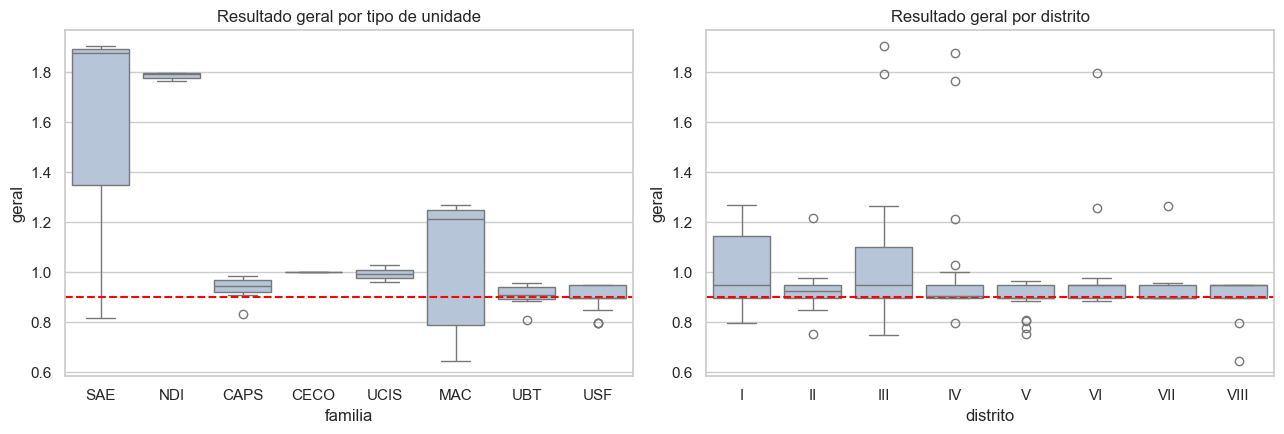

In [11]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=unidades, x='familia', y='geral', ax=eixos[0], color='lightsteelblue')
eixos[0].axhline(0.9, color='red', linestyle='--')
eixos[0].set_title('Resultado geral por tipo de unidade')
sns.boxplot(data=unidades, x='distrito', y='geral', order=sorted(unidades['distrito'].unique()), ax=eixos[1], color='lightsteelblue')
eixos[1].axhline(0.9, color='red', linestyle='--')
eixos[1].set_title('Resultado geral por distrito')
plt.tight_layout()
plt.show()

O tipo de unidade separa muito mais o resultado do que o distrito. NDI, SAE e parte das MAC ficam acima de 1, o que é investigado no nb 2

## Correlação

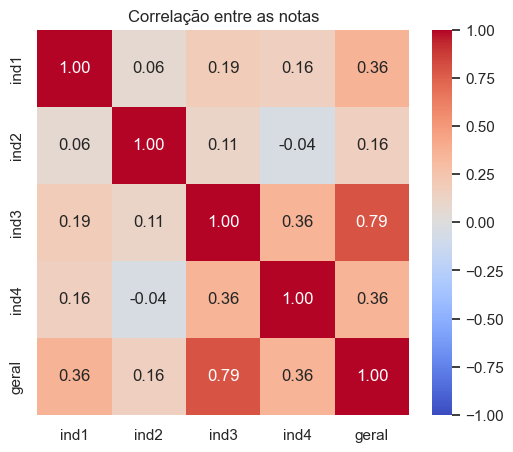

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(unidades[colunas].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre as notas')
plt.show()

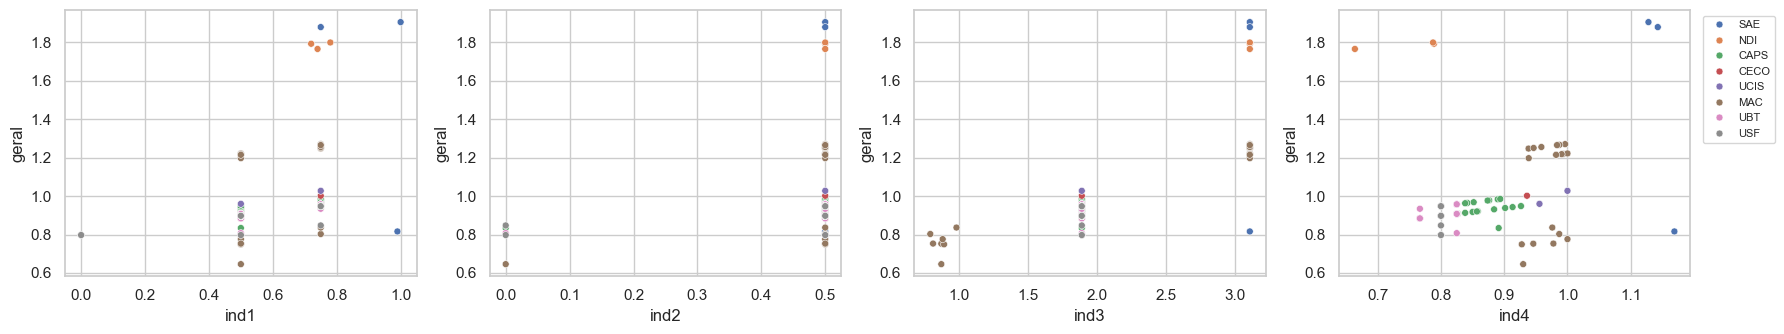

In [13]:
fig, eixos = plt.subplots(1, 4, figsize=(18, 3.5))
for eixo, coluna in zip(eixos, ['ind1', 'ind2', 'ind3', 'ind4']):
    sns.scatterplot(data=unidades, x=coluna, y='geral', hue='familia', ax=eixo, legend=(coluna == 'ind4'), s=25)
eixos[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

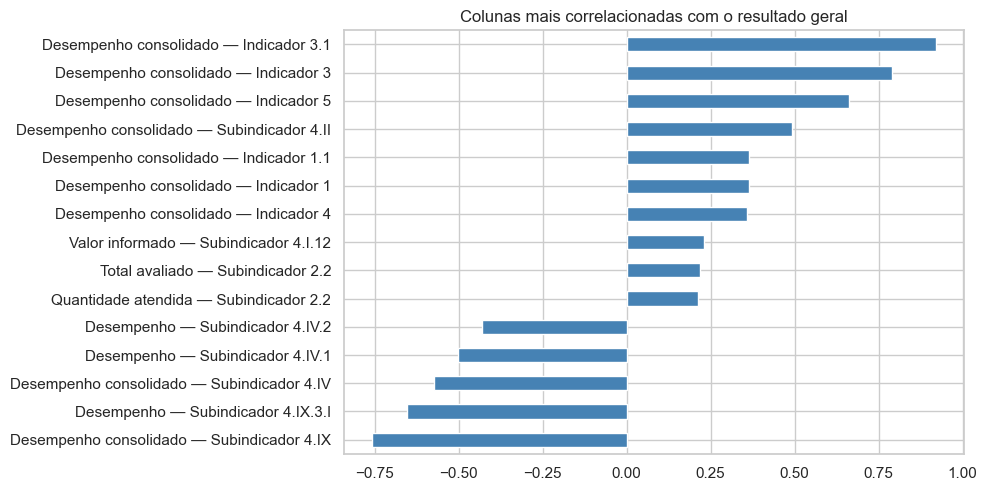

In [14]:
# correlação de cada coluna numérica da planilha com o resultado geral, só nas unidades.
# colunas constantes (as metas, por exemplo) não têm correlação definida e saem da conta.
# as notas dos indicadores 3, 4, 1 e 2 lideram; é delas que parte o feature engineering do caderno 2
brutas = convertida.loc[df['Tipo de unidade'] != 'DS', numericas]
brutas = brutas.loc[:, brutas.nunique() > 1]
correlacao_geral = brutas.drop(columns='Desempenho geral').corrwith(brutas['Desempenho geral'])
mais_correlatas = correlacao_geral[correlacao_geral.abs().sort_values(ascending=False).index].head(15)

mais_correlatas.sort_values().plot.barh(figsize=(8, 5.5), color='steelblue')
plt.title('Colunas mais correlacionadas com o resultado geral')
plt.show()

## Variável alvo da classificação

A classificação vai prever se a unidade fica **abaixo de 90%** no resultado geral. O corte de 90% separa os dois patamares em que a maior parte das USF se concentra (cerca de 0,90 e 0,95).

geral
90% ou mais      0.541
abaixo de 90%    0.459
Name: proportion, dtype: float64


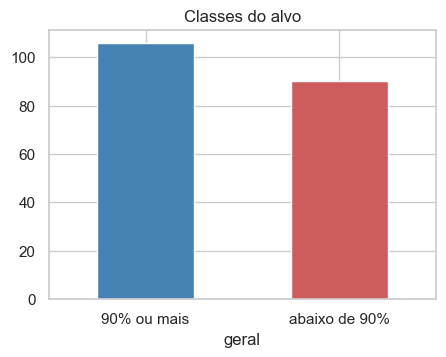

In [15]:
alvo = (unidades['geral'] < 0.9).map({True: 'abaixo de 90%', False: '90% ou mais'})
print(alvo.value_counts(normalize=True).round(3))

alvo.value_counts().plot.bar(color=['steelblue', 'indianred'], rot=0, figsize=(5, 3.5))
plt.title('Classes do alvo')
plt.show()

As classes estão quase equilibradas (cerca de 54% e 46%). Mesmo assim, no caderno 3 usamos separação estratificada e peso de classe nos modelos.

## Valores ausentes

In [16]:
print('qtd:', df.isna().sum().sum())

qtd: 0


colunas com algum ausente: 0 de 260
maior percentual: {'crua (%)': 0.0, 'convertida (%)': 0.0}


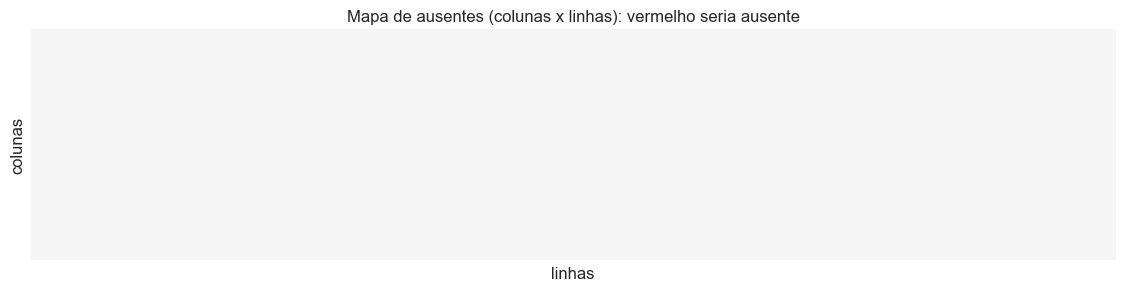

In [17]:
# percentual de ausentes por coluna, na leitura crua e depois de converter texto em número.
# a conversão usa errors='coerce', então qualquer valor ilegível viraria ausente aqui
faltantes = pd.DataFrame({'crua (%)': df.isna().mean() * 100, 'convertida (%)': convertida.isna().mean() * 100})
print('colunas com algum ausente:', (faltantes > 0).any(axis=1).sum(), 'de', len(faltantes))
print('maior percentual:', faltantes.max().to_dict())

fig, eixo = plt.subplots(figsize=(14, 3))
sns.heatmap(convertida.isna().T, cbar=False, cmap=['whitesmoke', 'indianred'], vmin=0, vmax=1,
            xticklabels=False, yticklabels=False, ax=eixo)
eixo.set_title('Mapa de ausentes (colunas x linhas): vermelho seria ausente')
eixo.set_xlabel('linhas')
eixo.set_ylabel('colunas')
plt.show()

In [18]:
df.loc[df['Tipo de unidade'] == 'DS', 'Valor informado — Subindicador 2.1'].head(3)

196      835.1000
197    1,821.4000
198      842.8000
Name: Valor informado — Subindicador 2.1, dtype: object

In [19]:
# outros problemas da planilha, além da vírgula de milhar acima
eh_unidade = df['Tipo de unidade'] != 'DS'
constantes = convertida.columns[convertida[eh_unidade].nunique() <= 1]
print('colunas constantes nas unidades (não informam nada ao modelo):', len(constantes))

# a mesma coluna mistura fração e percentual (0.8 e 80%); para_numero trata os dois
mistura = [c for c in df.columns[2:] if df[c].dtype == object
           and 0 < df[c].astype(str).str.endswith('%').mean() < 1]
print('colunas que misturam 0.8 e 80%:', len(mistura))

# a mesma meta escrita de dois jeitos; depois da conversão os valores coincidem
for coluna in [c for c in df.columns if c.startswith('Meta') and df[c].nunique() > 1]:
    print(coluna, df[coluna].unique().tolist(), '->', convertida[coluna].unique().tolist())

colunas constantes nas unidades (não informam nada ao modelo): 96


colunas que misturam 0.8 e 80%: 49
Meta — Subindicador 4.II.2 ['100%', '1.00'] -> [1.0]
Meta — Subindicador 4.IX.2 ['20', '2000%'] -> [20.0]
Meta — Subindicador 4.IX.3 ['4', '400%'] -> [4.0]
Meta — Subindicador 4.IX.3.1 ['8', '800%'] -> [8.0]


## Resumo

- 244 linhas, sendo 196 unidades e 48 linhas de distrito (`DS`), que saem da modelagem.
- Os números vêm como texto, com `%`, e precisam ser convertidos.
- As notas são assimétricas e há valores bem acima de 1 (NDI, SAE e MAC 1 e 2).
- O tipo de unidade explica muito mais o resultado do que o distrito.
- As classes do alvo estão quase equilibradas.
- Não há valores ausentes, mas alguns números das linhas de distrito usam vírgula de milhar.